In [ ]:
#importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(style='whitegrid')

In [ ]:
#uploading the wine csv file
from google.colab import files
uploaded= files.upload()
csv_file= next(iter(uploaded))
df=pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()


Saving WineQT.csv to WineQT.csv
Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
#numerical data types
no_columns= df.select_dtypes(include = "number")
print(no_columns)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

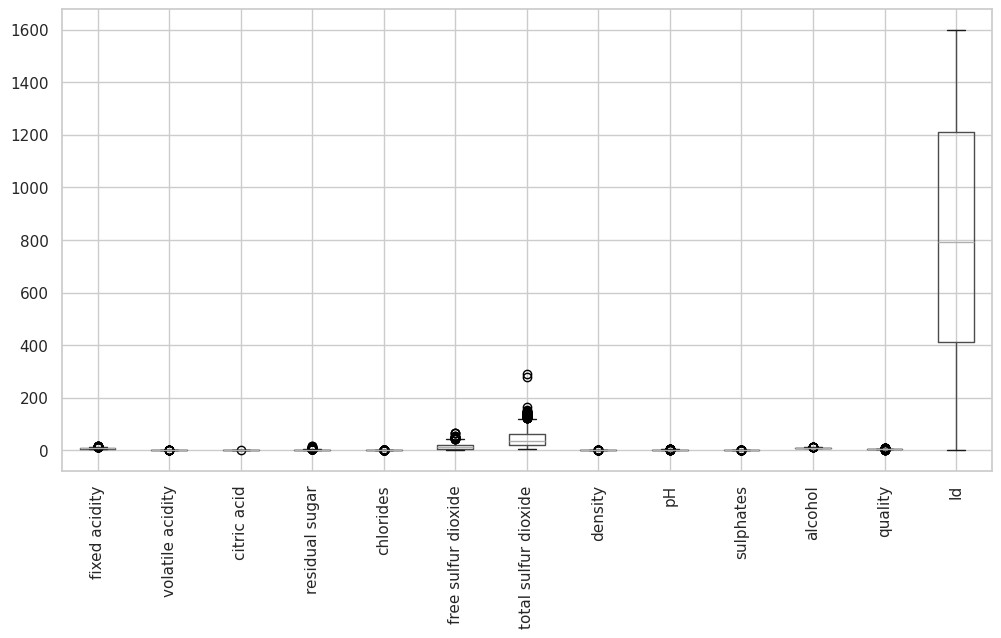

In [ ]:
no_columns.boxplot(figsize =(12,6))
plt.xticks(rotation = 90)
plt.show()

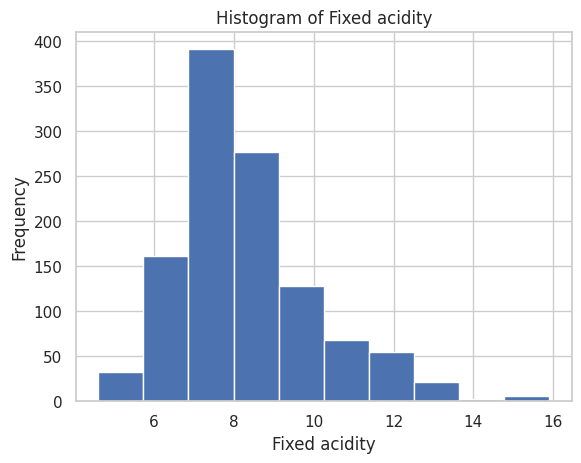

In [ ]:
#univariate analysis
import matplotlib.pyplot as plt
df['fixed acidity'].hist(bins=10)
plt.xlabel('Fixed acidity')
plt.ylabel('Frequency')
plt.title('Histogram of Fixed acidity')
plt.show()

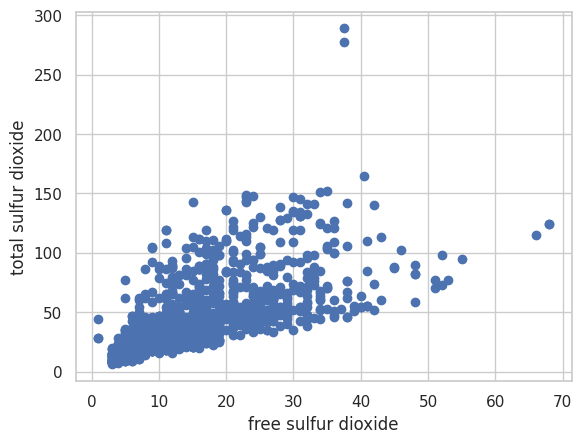

In [ ]:
#Bivariate analysis
plt.scatter(df['free sulfur dioxide'],df ['total sulfur dioxide'])
plt.xlabel('free sulfur dioxide')
plt.ylabel('total sulfur dioxide')
plt.show()

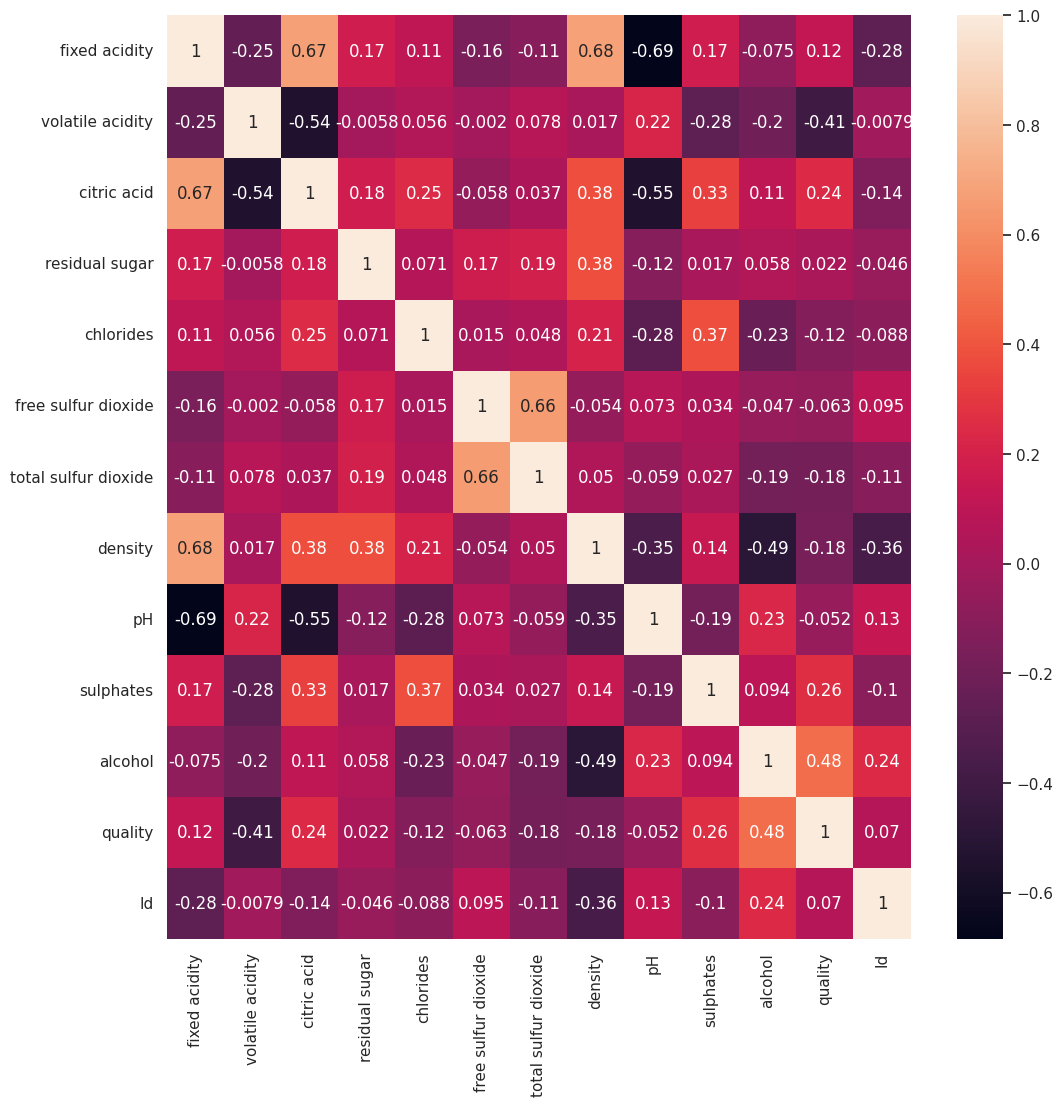

In [ ]:
#analysis by HEATMAP
import seaborn as sns
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(),annot=True)
plt.show()


In [ ]:
#separating x and y
x=df.drop(columns='Id')
y=df['Id']

In [ ]:
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
y.head()

,Id
0,0
1,1
2,2
3,3
4,4


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.5, random_state = 34)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


((571, 12), (572, 12), (571,), (572,))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
model= LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
y_pred= model.predict(X_test)
y_pred

array([1230.21159439,  889.14914532,  488.84712378, 1194.20531641,
        997.42017841,  931.6197642 ,  910.42422972,  834.3949982 ,
        984.00748111,  957.96898751,  698.59496529,  490.29743285,
        733.814735  ,  562.05795956,  437.389223  ,  563.54751191,
        729.40935938,  473.37978383,  872.09570067,  613.80860873,
        862.63186665,  529.92884319,  447.17900299,  933.80366186,
        603.39528435,  984.72574856,  852.77557361,  823.64651291,
       1045.10293013,  694.06747028,  733.43296771,  920.57234164,
        853.12043332, 1008.60850848,  629.34912756,  960.21411739,
        697.40057686,  772.2466446 , 1013.78366902,  760.50247653,
        562.37055821,  801.40856179,  653.91209626,  964.81657194,
        842.35365003,  761.96273737,  906.17125314,  289.04171238,
        935.30330137,  988.34844309,  712.99444082,  682.7128485 ,
        993.11015581,  784.02838908, 1059.81588852,  671.92006676,
        643.46069698,  889.61170496,  506.12735726,  276.70298

In [ ]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison.head(15)

,Actual,Predicted
98,144,1230.211594
1021,1433,889.149145
253,358,488.847124
779,1104,1194.205316
826,1169,997.420178
608,853,931.619764
1075,1506,910.424230
318,452,834.394998
1070,1499,984.007481
556,775,957.968988


In [ ]:
#mean squared error, mean absolute error and r2
mse= mean_squared_error(y_test, y_pred)
mae= mean_absolute_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 175741.89480797548
Mean Absolute Error: 343.1912685367089
R-squared: 0.14859357062368506


In [ ]:
new_data= pd.DataFrame({
    'fixed acidity':[7],
    'volatile acidity':[0.5],
    'citric acid':[0.2],
    'residual sugar':[1.0],
    'chlorides':[0.05],
    'free sulfur dioxide':[15.0],
    'total sulfur dioxide':[30.0],
    'density':[1.001],
    'pH':[3.5],
    'sulphates':[0.5],
    'alcohol':[9.0],
    'quality':[6],
    })
new_data_scaled = scaler.transform(new_data)
Id = model.predict(new_data_scaled)
print("Id Index:", Id[0])

Id Index: -61382.333576487064


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print("coeffiecents:",model.coef_)
print("intercept:",model.intercept_)

coeffiecents: [-7.51041098e+01  2.21737639e+02  2.78931478e+02  1.04508767e+01
  1.17776634e+02  1.28741834e+01 -4.72080139e+00 -5.12429389e+04
 -4.15301250e+02 -2.15459613e+02  5.49392269e+01 -1.16841789e+01]
intercept: 53282.4450881249


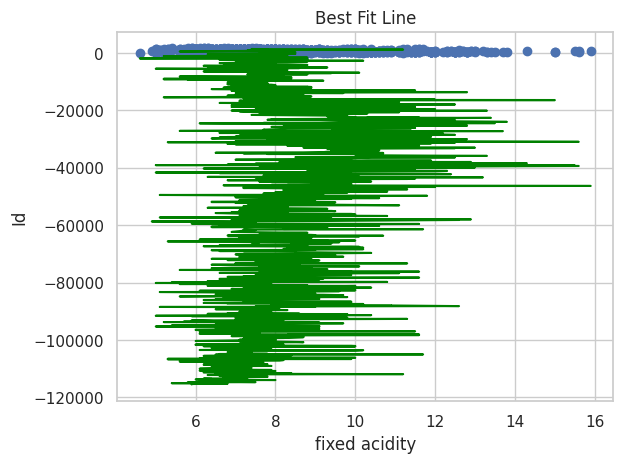

In [ ]:
#Best Fit Line
plt.scatter(df['fixed acidity'], df['Id'])
m, c = np.polyfit(df['fixed acidity'], df['Id'], 1)
plt.plot(df['fixed acidity'], m*df['Id'] + c, color='green')
plt.xlabel('fixed acidity')
plt.ylabel('Id')
plt.title('Best Fit Line')
plt.show()